# TASK-2  Unemployment Analysis with Python


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")  # hides annoying warning messages
sns.set_style("whitegrid")          #makes chart look cleaner

### Load the data and inspect

In [2]:
df = pd.read_csv("DataScience-Task2(Dataset)-Unemployment_Rate_upto_11_2020.csv")
print(df.shape)      
df.head()         

(267, 9)


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Region.1,longitude,latitude
0,Andhra Pradesh,31-01-2020,M,5.48,16635535,41.02,South,15.9129,79.74
1,Andhra Pradesh,29-02-2020,M,5.83,16545652,40.90,South,15.9129,79.74
2,Andhra Pradesh,31-03-2020,M,5.79,15881197,39.18,South,15.9129,79.74
3,Andhra Pradesh,30-04-2020,M,20.51,11336911,33.10,South,15.9129,79.74
4,Andhra Pradesh,31-05-2020,M,17.43,12988845,36.46,South,15.9129,79.74


In [3]:
df.info()           

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 9 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    267 non-null    object 
 1    Date                                     267 non-null    object 
 2    Frequency                                267 non-null    object 
 3    Estimated Unemployment Rate (%)          267 non-null    float64
 4    Estimated Employed                       267 non-null    int64  
 5    Estimated Labour Participation Rate (%)  267 non-null    float64
 6   Region.1                                  267 non-null    object 
 7   longitude                                 267 non-null    float64
 8   latitude                                  267 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 18.9+ KB


In [4]:
print(df.isnull().sum())   # number of missing values in column
print(df.duplicated().sum())  # number of duplicate rows

Region                                      0
 Date                                       0
 Frequency                                  0
 Estimated Unemployment Rate (%)            0
 Estimated Employed                         0
 Estimated Labour Participation Rate (%)    0
Region.1                                    0
longitude                                   0
latitude                                    0
dtype: int64
0


### Clean the data

In [5]:
# Check the original names first
print(df.columns)

Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Region.1', 'longitude', 'latitude'],
      dtype='object')


In [6]:
# Give simple names 
df.columns = ["State", "Date", "Frequency", "Unemployment_Rate",
              "Employed", "Labour_Participation_Rate",
              "Zone", "Longitude", "Latitude"]
# step A: remove the extra spaces from all column names
df.columns = df.columns.str.strip()

# step B: rename using a dictionary (old name -> new name)
df = df.rename(columns={
    "Region": "State",
    "Estimated Unemployment Rate (%)": "Unemployment_Rate",
    "Estimated Employed": "Employed",
    "Estimated Labour Participation Rate (%)": "Labour_Participation_Rate",
    "Region.1": "Zone",
    "longitude": "Longitude",
    "latitude": "Latitude"
})

print(df.columns)   # check the result

Index(['State', 'Date', 'Frequency', 'Unemployment_Rate', 'Employed',
       'Labour_Participation_Rate', 'Zone', 'Longitude', 'Latitude'],
      dtype='object')


In [7]:
# remove extra spaces from text columns
df["Date"] = df["Date"].str.strip()
df["Frequency"] = df["Frequency"].str.strip()
df["State"] = df["State"].str.strip()

# convert Date from text to real datetime (dayfirst because format is dd-mm-yyyy)
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# make extra columns from the date, useful later
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Year"] = df["Date"].dt.year

df.info()   # check Date is now datetime64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 266
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   State                      267 non-null    object        
 1   Date                       267 non-null    datetime64[ns]
 2   Frequency                  267 non-null    object        
 3   Unemployment_Rate          267 non-null    float64       
 4   Employed                   267 non-null    int64         
 5   Labour_Participation_Rate  267 non-null    float64       
 6   Zone                       267 non-null    object        
 7   Longitude                  267 non-null    float64       
 8   Latitude                   267 non-null    float64       
 9   Month                      267 non-null    int32         
 10  Month_Name                 267 non-null    object        
 11  Year                       267 non-null    int32         
dtypes: datet

In [8]:
df.describe()   

,Date,Unemployment_Rate,Employed,Labour_Participation_Rate,Longitude,Latitude,Month,Year
count,267,267.000000,2.670000e+02,267.000000,267.000000,267.000000,267.000000,267.0
mean,2020-06-16 09:15:30.337078528,12.236929,1.396211e+07,41.681573,22.826048,80.532425,5.535581,2020.0
min,2020-01-31 00:00:00,0.500000,1.175420e+05,16.770000,10.850500,71.192400,1.000000,2020.0
25%,2020-03-31 00:00:00,4.845000,2.838930e+06,37.265000,18.112400,76.085600,3.000000,2020.0
50%,2020-06-30 00:00:00,9.650000,9.732417e+06,40.390000,23.610200,79.019300,6.000000,2020.0
75%,2020-08-31 00:00:00,16.755000,2.187869e+07,44.055000,27.278400,85.279900,8.000000,2020.0
max,2020-10-31 00:00:00,75.850000,5.943376e+07,69.690000,33.778200,92.937600,10.000000,2020.0
std,NaN,10.803283,1.336632e+07,7.845419,6.270731,5.831738,2.870915,0.0


### Region-wise Averages

In [9]:
# average unemployment rate for each state
state_avg = df.groupby("State")["Unemployment_Rate"].mean().sort_values(ascending=False)
print(state_avg)

State
Haryana             27.477000
Tripura             25.055000
Jharkhand           19.539000
Bihar               19.471000
Delhi               18.414000
Puducherry          17.942000
Jammu & Kashmir     16.477778
Himachal Pradesh    16.065000
Rajasthan           15.868000
Tamil Nadu          12.187000
Goa                 12.167000
Punjab              11.981000
Uttarakhand         11.156000
West Bengal         10.192000
Sikkim               9.792500
Uttar Pradesh        9.737000
Kerala               9.434000
Andhra Pradesh       8.664000
Maharashtra          7.979000
Chhattisgarh         7.819000
Karnataka            7.668000
Madhya Pradesh       6.854000
Telangana            6.833000
Odisha               6.462000
Gujarat              6.376000
Assam                4.856000
Meghalaya            3.866000
Name: Unemployment_Rate, dtype: float64


In [10]:
# Average by zone (north,south,east,west)
zone_avg = df.groupby("Zone")["Unemployment_Rate"].mean().sort_values(ascending=False)
print(zone_avg) 

Zone
North        15.889620
East         13.916000
Northeast    10.950263
South        10.454667
West          8.239000
Name: Unemployment_Rate, dtype: float64


### Month- wise trend

In [11]:
# average unemployment rate across all states for each month
monthly_avg = df.groupby("Date")["Unemployment_Rate"].mean()
print(monthly_avg)


Date
2020-01-31     9.196538
2020-02-29     9.266154
2020-03-31    10.782593
2020-04-30    22.236154
2020-05-31    23.244444
2020-06-30    10.911111
2020-07-31     9.834444
2020-08-31    10.313333
2020-09-30     8.705926
2020-10-31     8.026296
Name: Unemployment_Rate, dtype: float64


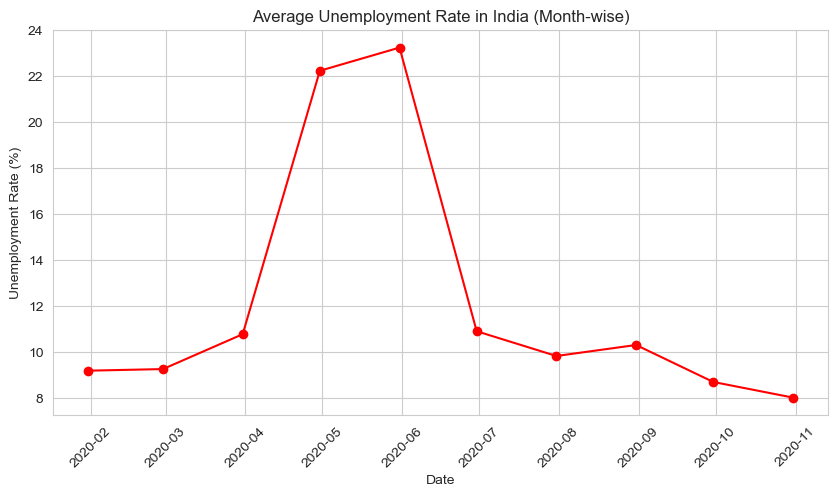

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker="o", color="red")
plt.title("Average Unemployment Rate in India (Month-wise)")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=45)
plt.show()

### Time-series line chart for 3+ states

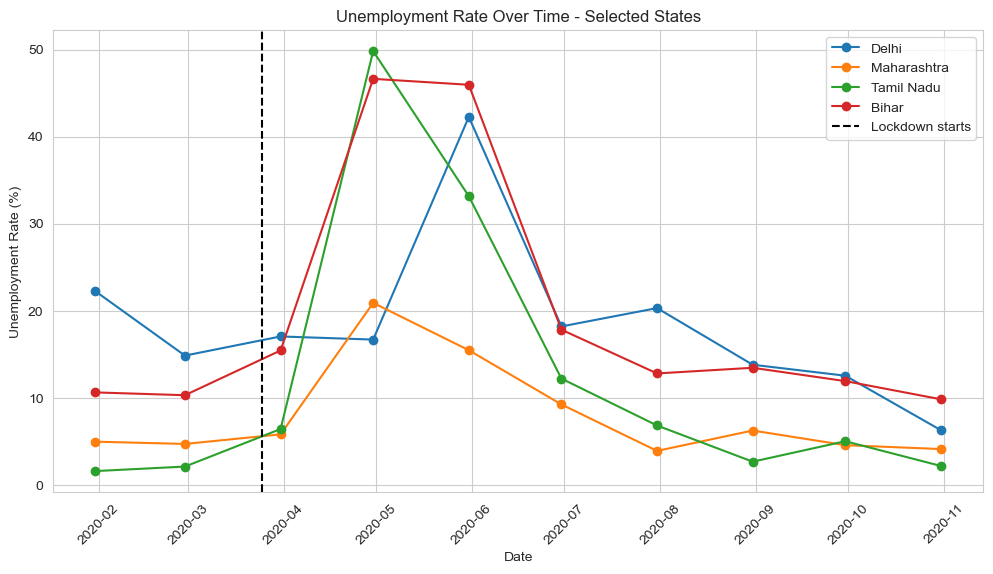

In [13]:
states_to_plot = ["Delhi", "Maharashtra", "Tamil Nadu", "Bihar"]

plt.figure(figsize=(12, 6))

for s in states_to_plot:
    one_state = df[df["State"] == s]          # keep only this state's rows
    one_state = one_state.sort_values("Date")  # sort by date so the line is correct
    plt.plot(one_state["Date"], one_state["Unemployment_Rate"], marker="o", label=s)

# draw a vertical line where the lockdown started (25 March 2020)
plt.axvline(pd.to_datetime("2020-03-25"), color="black", linestyle="--", label="Lockdown starts")

plt.title("Unemployment Rate Over Time - Selected States")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

### Bar Chart, Top 10 states by average unemployment

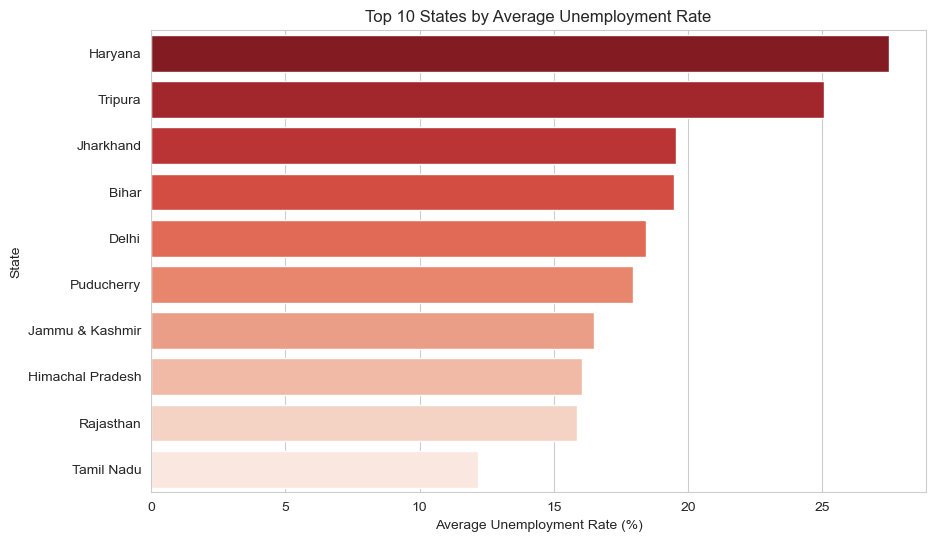

In [14]:
top10 = df.groupby("State")["Unemployment_Rate"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top10.values, y=top10.index, palette="Reds_r")
plt.title("Top 10 States by Average Unemployment Rate")
plt.xlabel("Average Unemployment Rate (%)")
plt.ylabel("State")
plt.show()

### Correlation Heatmap

In [15]:
cols = ["Unemployment_Rate", "Employed", "Labour_Participation_Rate"]
corr = df[cols].corr()
print(corr)

                           Unemployment_Rate  Employed  \
Unemployment_Rate                   1.000000 -0.245176   
Employed                           -0.245176  1.000000   
Labour_Participation_Rate          -0.073540 -0.047948   

                           Labour_Participation_Rate  
Unemployment_Rate                          -0.073540  
Employed                                   -0.047948  
Labour_Participation_Rate                   1.000000  


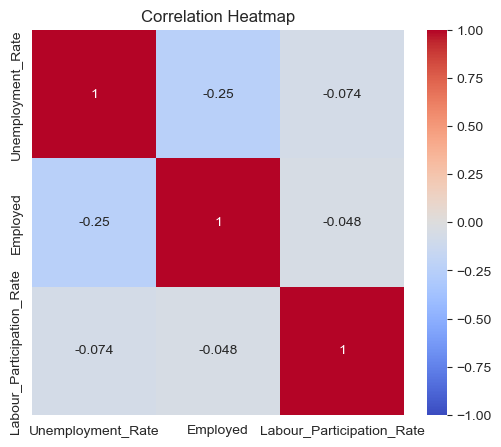

In [16]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()

### Pre-Covid vs. post-Covid Comparison

In [17]:
cutoff = pd.to_datetime("2020-04-01")

pre_covid = df[df["Date"] < cutoff]
post_covid = df[df["Date"] >= cutoff]

print("Pre-COVID months :", pre_covid["Date"].nunique())
print("Post-COVID months:", post_covid["Date"].nunique())

Pre-COVID months : 3
Post-COVID months: 7


In [18]:
# overall mean of each rate in both periods
pre_mean = pre_covid[["Unemployment_Rate", "Labour_Participation_Rate"]].mean()
post_mean = post_covid[["Unemployment_Rate", "Labour_Participation_Rate"]].mean()

comparison = pd.DataFrame({"Pre-COVID": pre_mean, "Post-COVID": post_mean})
print(comparison)

                           Pre-COVID  Post-COVID
Unemployment_Rate           9.761519   13.277128
Labour_Participation_Rate  44.179114   40.632074


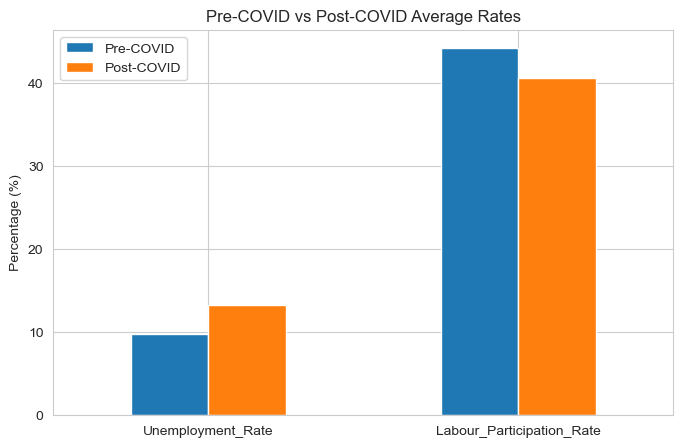

In [19]:
comparison.plot(kind="bar", figsize=(8, 5))
plt.title("Pre-COVID vs Post-COVID Average Rates")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.show()

In [20]:
pre_state = pre_covid.groupby("State")["Unemployment_Rate"].mean()
post_state = post_covid.groupby("State")["Unemployment_Rate"].mean()

change = pd.DataFrame({"Pre": pre_state, "Post": post_state})
change["Increase"] = change["Post"] - change["Pre"]
change = change.sort_values("Increase", ascending=False)
print(change.head(10))

                      Pre       Post   Increase
State                                          
Puducherry       1.180000  25.125714  23.945714
Jharkhand       10.230000  23.528571  13.298571
Tamil Nadu       3.353333  15.972857  12.619524
Bihar           12.110000  22.625714  10.515714
Goa              5.650000  14.960000   9.310000
Karnataka        3.310000   9.535714   6.225714
West Bengal      6.260000  11.877143   5.617143
Haryana         23.720000  29.087143   5.367143
Madhya Pradesh   3.633333   8.234286   4.600952
Rajasthan       12.676667  17.235714   4.559048
